# Background Information

This dataset comes from Kaggle and is compiled as part of the Abracadabra project. It contains approximately 550,000 Spotify tracks with lyrics, emotion labels, and audio features per song including tempo, energy, danceability, acousticness, and more. The dataset has 39 columns and utilizes a wide range of songs.

**Our central question is: how well audio features predict if a song is good for studying/doing work?** This is important because platforms like Spotify heavily rely on audio characteristics, such as tempo, key, loudness, and danceability, to suggest and curate playlist recommendations for users based on their mood and listening habits.

If audio features can reliably predict whether a song will improve a student's productivity and work performance, Spotify would greatly benefit from the success. This success would lead to ultimately more subscriptions and listening hours. Studies have shown that when a student listens to 'good study music' their productivity will increase compared to distracting and even no music at all. For example, slower tempo, and low danceability can put a student in the locked in zone. When in contrast fast moving songs that are 'Good for Party' would lead a student to distraction and poor work production. By identifying these patterns, recommendation algorithms can generate playlists for users such as 'study mode', 'in the library', or 'academic weapon!' with greater precision.

At the same time, personal experience does play an important role in music and how individuals utilize songs in different settings. This may not be captured in the data. This means that while audio features may provide useful signals about songs, they likely offer an incomplete picture of how much productivity a song can foster.

We will explore this question of if audio features can predict if a song is good for studying or not and what features lead to this decision to find if we can create a model to accurately predict this binary classification. We want to see if data alone, not accounting for personal experience, can classify songs correctly.

We will approach this with two models:
1. **Logistic Regression**: supervised exploration of whether songs can be classified right or left of the good for study threshold using features such as tempo, instrumentalness, and other numeric values
2. **Decision Tree**: a formal classification model to predict if a song is good for studying and will promote productivity

# Imports and Load Data 

In [1]:
#load libraries
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, accuracy_score, precision_score

/workspaces/ML_Final_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the dataset from Kaggle
# 1. This handles the login and download
# It will prompt you for your username and key from the json file
path = kagglehub.dataset_download("devdope/900k-spotify")

# 2. Load the specific CSV from that path
# The file in this dataset is named 'spotify_dataset.csv'
df = pd.read_csv(f"{path}/spotify_dataset.csv")

print(df.head())


  Artist(s)                       song  \
0       !!!  Even When the Waters Cold   
1       !!!         One Girl / One Boy   
2       !!!          Pardon My Freedom   
3       !!!                        Ooo   
4       !!!                 Freedom 15   

                                                text Length  emotion    Genre  \
0  Friends told her she was better off at the bot...  03:47  sadness  hip hop   
1  Well I heard it, playing soft From a drunken b...  04:03  sadness  hip hop   
2  Oh my god, did I just say that out loud? Shoul...  05:51      joy  hip hop   
3  [Verse 1] Remember when I called you on the te...  03:44      joy  hip hop   
4  [Verse 1] Calling me like I got something to s...  06:00      joy  hip hop   

           Album       Release Date     Key  Tempo  ...  \
0       Thr!!!er    29th April 2013   D min    105  ...   
1       Thr!!!er    29th April 2013  A# min    117  ...   
2  Louden Up Now      8th June 2004   A Maj    121  ...   
3          As If  16th O

# EDA

In [3]:
# explore the dataset's columns, non-null count, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  str    
 1   song                            551427 non-null  str    
 2   text                            551443 non-null  str    
 3   Length                          551443 non-null  str    
 4   emotion                         551443 non-null  str    
 5   Genre                           551443 non-null  str    
 6   Album                           551391 non-null  str    
 7   Release Date                    551443 non-null  str    
 8   Key                             551443 non-null  str    
 9   Tempo                           551443 non-null  int64  
 10  Loudness (db)                   551443 non-null  str    
 11  Time signature                  551435 non-null  str    
 12  Explicit                   

In [4]:
# get a summary statistics of the dataset
df.describe()

,Tempo,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness,Good for Party,...,Good for Relaxation/Meditation,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similarity Score 1,Similarity Score 2,Similarity Score 3
count,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,...,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000
mean,120.513567,32.258106,62.661874,59.195460,47.738330,11.663980,19.655658,25.748436,7.152255,0.061809,...,0.030772,0.187334,0.053842,0.021484,0.057797,0.012253,0.066215,0.984107,0.979013,0.975938
std,29.185533,18.033931,22.399159,17.511007,24.159671,12.342389,16.274817,29.343731,20.589200,0.240808,...,0.172700,0.390180,0.225707,0.144990,0.233360,0.110014,0.248658,0.013559,0.015438,0.016512
min,31.000000,0.000000,0.000000,6.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002656,0.002647,0.002647
25%,97.000000,20.000000,48.000000,47.000000,28.000000,4.000000,10.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977433,0.971582,0.967926
50%,120.000000,30.000000,65.000000,60.000000,47.000000,6.000000,13.000000,12.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.985926,0.980971,0.978078
75%,140.000000,43.000000,80.000000,72.000000,66.000000,15.000000,25.000000,43.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993567,0.988592,0.986079
max,200.000000,100.000000,100.000000,99.000000,100.000000,97.000000,100.000000,100.000000,100.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# print column names
print(df.columns) 


Index(['Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album',
       'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness',
       'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness',
       'Good for Party', 'Good for Work/Study',
       'Good for Relaxation/Meditation', 'Good for Exercise',
       'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving',
       'Good for Social Gatherings', 'Good for Morning Routine',
       'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1',
       'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2',
       'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3'],
      dtype='str')


In [6]:
# see the total na values in each column
df.isna().sum()

Artist(s)                          0
song                              16
text                               0
Length                             0
emotion                            0
Genre                              0
Album                             52
Release Date                       0
Key                                0
Tempo                              0
Loudness (db)                      0
Time signature                     8
Explicit                           0
Popularity                         0
Energy                             0
Danceability                       0
Positiveness                       0
Speechiness                        0
Liveness                           0
Acousticness                       0
Instrumentalness                   0
Good for Party                     0
Good for Work/Study                0
Good for Relaxation/Meditation     0
Good for Exercise                  0
Good for Running                   0
Good for Yoga/Stretching           0
G

In [7]:
# drop columns not needed for analysis
# since all the columns with missing values are included here, no need to drop them separately
df = df.drop(columns=['song', 'text', 'Length', 'Genre', 'Album', 'Release Date', 'Artist(s)', 'Time signature', 'Similar Artist 1', 'Similar Artist 2', 'Similar Artist 3', 'Similar Song 1', 'Similar Song 2', 'Similar Song 3', 'Similarity Score 1', 'Similarity Score 2', 'Similarity Score 3'])
# drop all the 'Good for ___' columns due to data leakage concerns except the target variable 'Good for Work/Study' becuase will drop later after creating target variable
df = df.drop(columns=['Good for Party', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine'])
# confirm the columns have been dropped
df.columns

Index(['emotion', 'Key', 'Tempo', 'Loudness (db)', 'Explicit', 'Popularity',
       'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness',
       'Acousticness', 'Instrumentalness', 'Good for Work/Study'],
      dtype='str')

In [8]:
# create x and y dataset for modeling
y = df['Good for Work/Study']

# drop target variable from X dataset along 
X = df.drop(columns=['Good for Work/Study'])

In [9]:
# make sure Good for Work/Study is dropped from X dataset
print(X.columns)
# print the shape of X and y to confirm they are the same length
print(X.shape)
print(y.shape)

Index(['emotion', 'Key', 'Tempo', 'Loudness (db)', 'Explicit', 'Popularity',
       'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness',
       'Acousticness', 'Instrumentalness'],
      dtype='str')
(551443, 13)
(551443,)


In [10]:
# get the number of unique values in the target variable and the count of each value
print(y.nunique())
print(y.value_counts())

2
Good for Work/Study
0    510123
1     41320
Name: count, dtype: int64


In [11]:
# calculate the prevalence of the target variable
prevalence = y.value_counts()[1] / len(y)
print(f"Prevalence of Good for Work/Study: {prevalence:.2f}")

Prevalence of Good for Work/Study: 0.07


For the categorical columns, do additional EDA on them:

In [12]:
# view value counts of emotion column and print the number of unique values
print(X['emotion'].nunique())
X['emotion'].value_counts()


13


emotion
joy          209009
sadness      171078
anger        109678
fear          28097
love          27963
surprise       5592
True             17
Love              3
pink              2
angry             1
thirst            1
confusion         1
interest          1
Name: count, dtype: int64

In [13]:
# Clean up the emotion column more to ensure consistency and collapse rare emotions into other
X['emotion'] = X['emotion'].replace('Love','love')
X['emotion'] = X['emotion'].replace('angry','anger')
X['emotion'] = X['emotion'].replace(['surprise', 'True', 'pink', 'thirst', 'confusion', 'interest'],'other')
# view value counts of emotion column and print the number of unique values after cleaning
print(X['emotion'].nunique())
X['emotion'].value_counts()

6


emotion
joy        209009
sadness    171078
anger      109679
fear        28097
love        27966
other        5614
Name: count, dtype: int64

In [14]:
# view value counts of key column and print the number of unique values
print(X['Key'].nunique())
X['Key'].value_counts()


24


Key
C Maj     47745
G Maj     47465
D Maj     44568
C# Maj    44409
A Maj     33849
G# Maj    26045
B min     25772
E min     22348
F Maj     22298
A min     21094
A# min    20261
B Maj     19764
E Maj     19633
F# min    19529
F# Maj    19470
F min     19073
C# min    18583
A# Maj    16250
G min     14558
C min     12224
D min     10455
G# min    10293
D# Maj     9233
D# min     6524
Name: count, dtype: int64

In [16]:
# collapse into 2 categories: Major or Minor
# first make it all lower case to ensure consistency
# then use .apply to create a funciton so if it contains 'maj' it will be categorized as 'major', and if not it will be 'minor'
X['Key'] = X['Key'].str.lower().apply(lambda x: 'major' if 'maj' in x else 'minor')
# view value counts of key column and print the number of unique values after collapsing
print(X['Key'].nunique())
X['Key'].value_counts()

2


Key
major    350729
minor    200714
Name: count, dtype: int64

In [17]:
# view value counts of Loudness (db) column and print the number of unique values
print(X['Loudness (db)'].nunique())
X['Loudness (db)'].value_counts()


3746


Loudness (db)
-6db        10611
-7db         8986
-5db         8221
-8db         7010
-4db         6528
            ...  
3.64db          1
-47.06db        1
-36.07db        1
-28.62db        1
-43.72db        1
Name: count, Length: 3746, dtype: int64

In [18]:
# strip the 'db' from the Loudness (db) column and convert to numeric
X['Loudness (db)'] = X['Loudness (db)'].str.replace('db', '').astype(float)
# verify dtype
print(X['Loudness (db)'].dtype)
print(X['Loudness (db)'].head())

float64
0   -6.85
1   -5.75
2   -6.06
3   -5.42
4   -5.57
Name: Loudness (db), dtype: float64


In [19]:
# view value counts of Explicit column and print the number of unique values
print(X['Explicit'].nunique())
X['Explicit'].value_counts()


2


Explicit
No     389378
Yes    162065
Name: count, dtype: int64

### Graphs with an Emphasis on Variables we Believe to be Important For Analysis

In [20]:
# print the datatypes of X
print(X.dtypes)

emotion                 str
Key                     str
Tempo                 int64
Loudness (db)       float64
Explicit                str
Popularity            int64
Energy                int64
Danceability          int64
Positiveness          int64
Speechiness           int64
Liveness              int64
Acousticness          int64
Instrumentalness      int64
dtype: object


<Axes: >

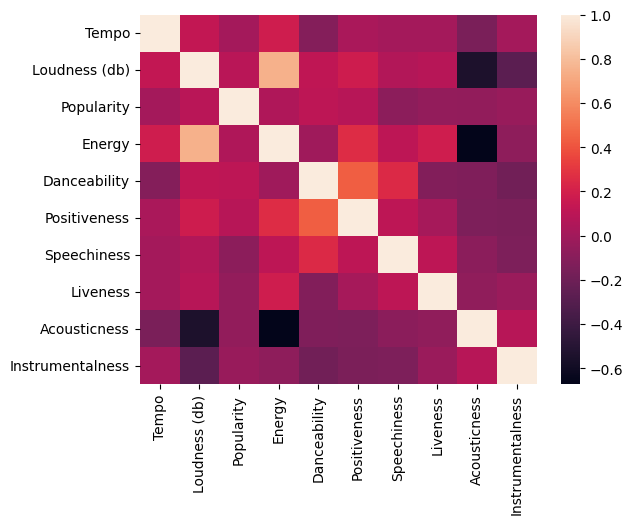

In [21]:
# print a correlation matrix only using the numeric data types in X
numeric_features = X.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_features.corr()
sns.heatmap(corr_matrix)

In [22]:
# create categorical features 
categorical_features = X.select_dtypes(include=['str'])

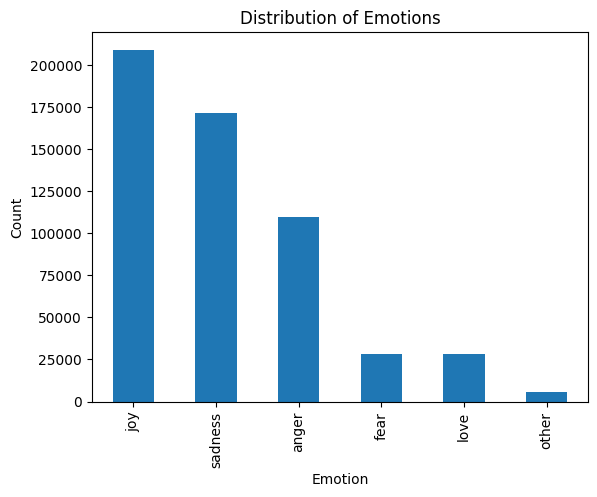

In [26]:
# see the distribution of the categorical features, start with emotion then do Key and Explicit
categorical_features['emotion'].value_counts().plot(kind='bar')
plt.title("Distribution of Emotions")
plt.ylabel("Count")
plt.xlabel("Emotion")
plt.show()

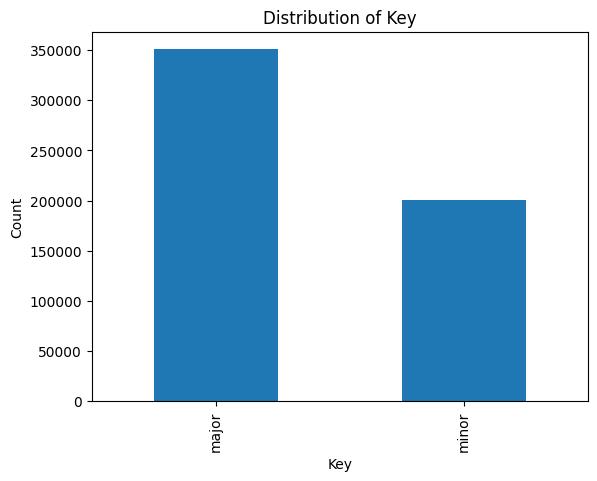

In [27]:
# Key
categorical_features['Key'].value_counts().plot(kind='bar')
plt.title("Distribution of Key")
plt.ylabel("Count")
plt.xlabel("Key")
plt.show()

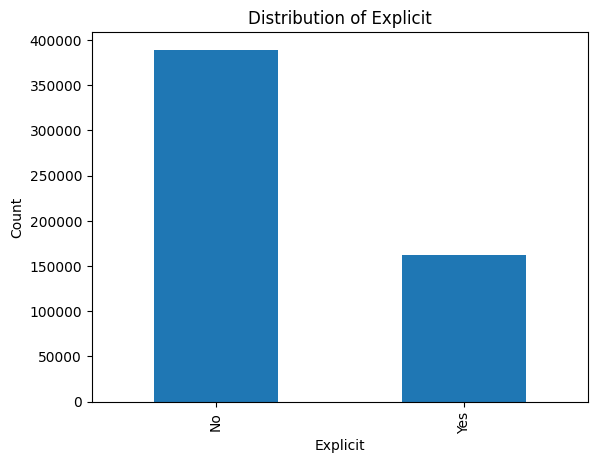

In [28]:
#Explicit
categorical_features['Explicit'].value_counts().plot(kind='bar')
plt.title("Distribution of Explicit")
plt.ylabel("Count")
plt.xlabel("Explicit")
plt.show()